# **Classification**
* Binary
* Multiclass
* Multilabel

https://cs231n.github.io/neural-networks-case-study/

## Data

In [1]:
from sklearn.datasets import make_circles

samples = 1000

x, y = make_circles(samples,
                    noise=0.03,
                    random_state=42)
x

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

In [2]:
y[:10]

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0])

In [3]:
import pandas as pd

circles = pd.DataFrame({"x0": x[:, 0], "x1": x[:, 1], "label": y})
circles

,x0,x1,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
...,...,...,...
995,0.244054,0.944125,0
996,-0.978655,-0.272373,0
997,-0.136900,-0.810012,1
998,0.670362,-0.767502,0


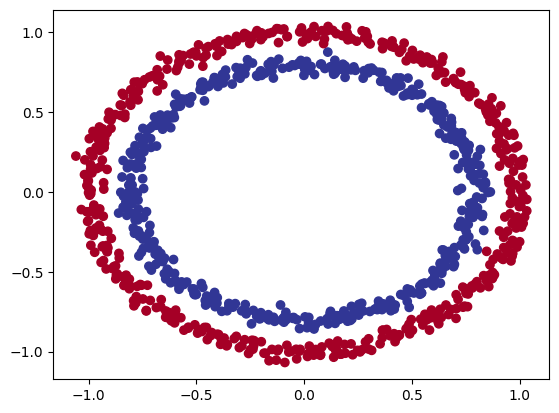

In [4]:
from matplotlib import pyplot as plt
plt.scatter(x[:, 0], x[:, 1], c=y, cmap=plt.cm.RdYlBu)

## Structure of Data

In [5]:
x.shape, y.shape

((1000, 2), (1000,))

In [6]:
len(x), len(y)

(1000, 1000)

## Modeling

* create Model
* compile
* fit
* evaluate
* tweak
* evaluate

In [7]:
import tensorflow as tf
tf.__version__
tf.random.set_seed(42)

In [8]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])
model.compile(loss=tf.keras.losses.BinaryCrossentropy(),
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["accuracy"])
model.fit(x, y, epochs=5, verbose=2)

Epoch 1/5
32/32 - 2s - 64ms/step - accuracy: 0.4710 - loss: 4.5339
Epoch 2/5
32/32 - 0s - 5ms/step - accuracy: 0.4930 - loss: 1.1504
Epoch 3/5
32/32 - 0s - 5ms/step - accuracy: 0.5020 - loss: 0.7092
Epoch 4/5
32/32 - 0s - 5ms/step - accuracy: 0.4930 - loss: 0.6987
Epoch 5/5
32/32 - 0s - 3ms/step - accuracy: 0.4920 - loss: 0.6956


In [9]:
model.evaluate(x, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4617 - loss: 0.6958  


[0.6937984228134155, 0.4860000014305115]

In [10]:
model.fit(x, y, epochs=200, verbose=0)
model.evaluate(x, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4852 - loss: 0.6927


[0.6932879686355591, 0.4729999899864197]

In [11]:
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(1)
])

model_1.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=["accuracy"])
model_1.fit(x, y, epochs=100, verbose=0)
model_1.evaluate(x, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0041


[0.004629754461348057, 1.0]

In [56]:
## spliting since it has overfitting
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model_1.fit(x_train, y_train, epochs=10, verbose=0)


In [13]:
model_1.evaluate(x_test, y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0071 


[0.007049378007650375, 1.0]

In [14]:
plt.scatter

<function matplotlib.pyplot.scatter(x: 'float | ArrayLike', y: 'float | ArrayLike', s: 'float | ArrayLike | None' = None, c: 'ArrayLike | Sequence[ColorType] | ColorType | None' = None, *, marker: 'MarkerType | None' = None, cmap: 'str | Colormap | None' = None, norm: 'str | Normalize | None' = None, vmin: 'float | None' = None, vmax: 'float | None' = None, alpha: 'float | None' = None, linewidths: 'float | Sequence[float] | None' = None, edgecolors: "Literal['face', 'none'] | ColorType | Sequence[ColorType] | None" = None, colorizer: 'Colorizer | None' = None, plotnonfinite: 'bool' = False, data=None, **kwargs) -> 'PathCollection'>

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
def plot_decision_boundary(model, x, y):
    x_min, x_max = x[:, 0].min() - 0.1, x[:, 0].max() + 0.1
    y_min, y_max = x[:, 1].min() - 0.1, x[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))

    x_in = np.c_[xx.ravel(), yy.ravel()]
    y_pred = model.predict(x_in)

    if model.output_shape[-1] > 1:
        y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
    else:
        y_pred = y_pred.reshape(xx.shape)

    # Draw only the decision boundary
    plt.contour(xx, yy, y_pred, levels=[0.5], cmap=plt.cm.RdYlBu, linewidths=2, alpha=0.7)
    plt.scatter(x[:, 0], x[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


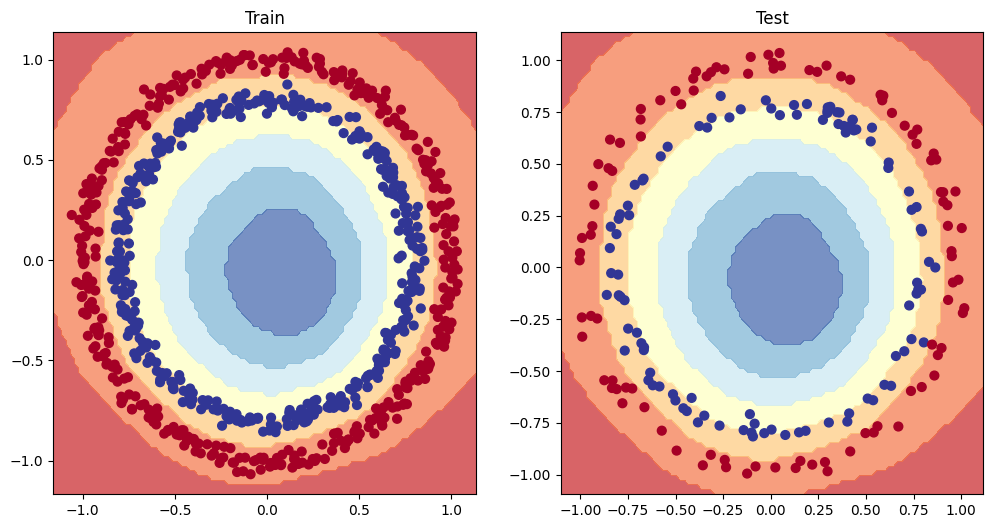

In [16]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, x_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, x_test, y_test)
plt.show()

In [17]:
p = model_1.predict(x)
p[:10]

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


array([[ 2.2476478 ],
       [ 2.0840814 ],
       [ 1.2834754 ],
       [ 1.9259588 ],
       [-0.86613333],
       [ 1.5320649 ],
       [ 1.8435462 ],
       [ 2.2359133 ],
       [ 2.0884256 ],
       [-0.43243048]], dtype=float32)

## Regression



In [18]:
x_reg = tf.range(1, 1000, 5)
y_reg = tf.range(100, 1100, 5)

#split - Dense layer expects 2D
x_train = tf.reshape(x_train, (-1, 1))
x_test = tf.reshape(x_test, (-1, 1))
y_train = tf.reshape(y_train, (-1, 1))
y_test = tf.reshape(y_test, (-1, 1))

# x_train, y_train

In [22]:
import tensorflow as tf
from sklearn.model_selection import train_test_split

tf.random.set_seed(42)

# Split the original x and y data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(1)
])
model_3.compile(loss=["mae"],
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=["accuracy"])
model_3.fit(x_train, y_train, epochs=100, verbose=0)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


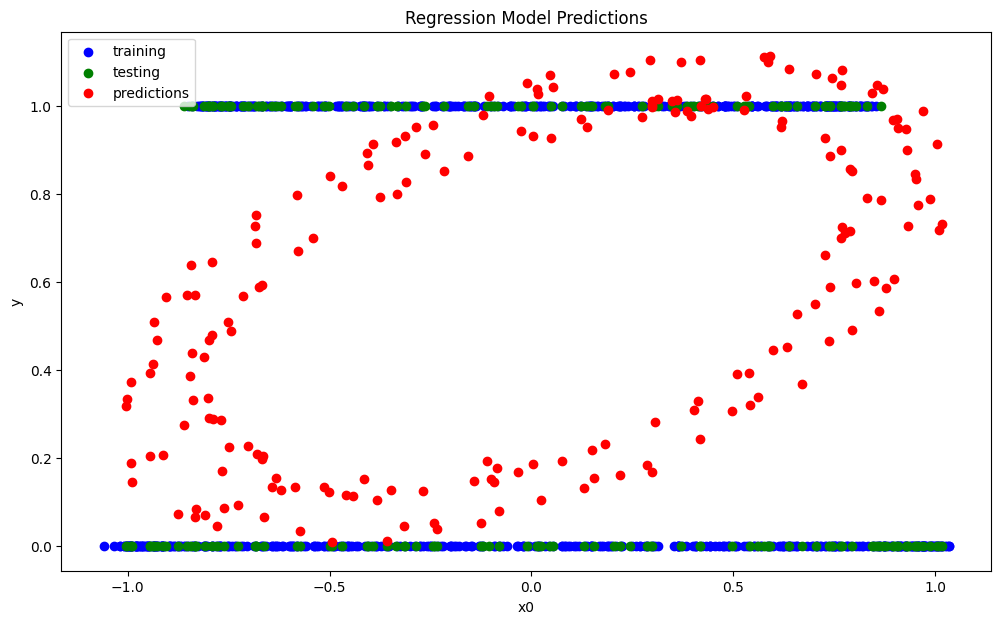

((800,), (800, 2))

In [55]:
y_pred = model_3.predict(x_test)

plt.figure(figsize=(12, 7))
plt.scatter(x_train[:, 0], y_train, c="b", label="training")
plt.scatter(x_test[:, 0], y_test, c="g", label="testing")
plt.scatter(x_test[:, 0], y_pred[:, 0], c="r", label="predictions") # Select the first dimension of y_pred
plt.xlabel("x0")
plt.ylabel("y")
plt.title("Regression Model Predictions")
plt.legend()
plt.show()

y_train.shape, x_train.shape

In [54]:
tf.random.set_seed(42)

model_4 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation=tf.keras.activations.linear)
])
model_4.compile(loss="binary_crossentropy",
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=["accuracy"])
model_4.fit(x, y, epochs=100, verbose=0)

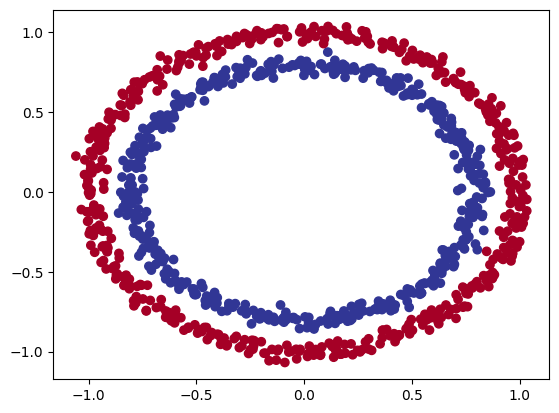

In [25]:
plt.scatter(x[:, 0], x[:, 1], c=y, cmap=plt.cm.RdYlBu)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 969us/step


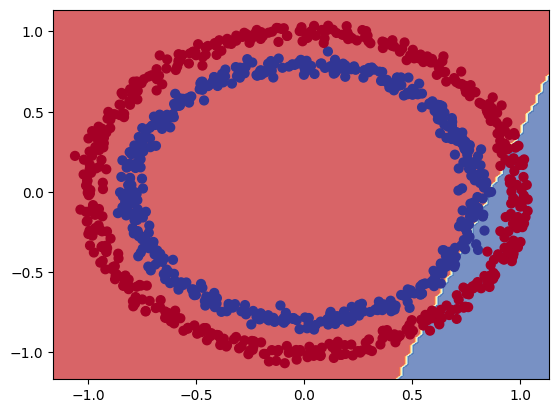

In [26]:
# decision Boundary
plot_decision_boundary(model_4, x, y)

In [53]:
model_5 = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(100, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(1, activation=tf.keras.activations.relu)
])
model_5.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=["accuracy"])
history = model_5.fit(x, y, epochs=100, verbose=0)

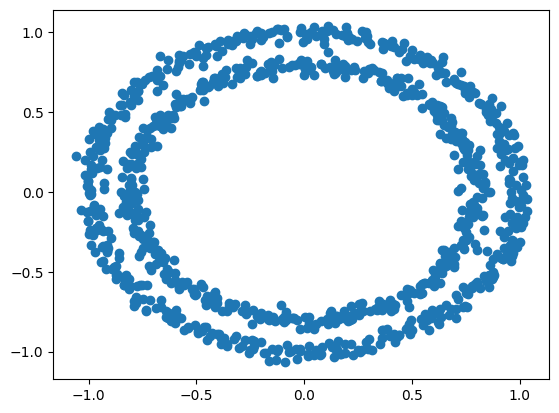

In [28]:
plt.scatter(x[:, 0], x[:, 1])

In [41]:
model_6 = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(1)
])
model_6.compile(loss=tf.keras.losses.BinaryCrossentropy,
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=["accuracy"])
history = model_6.fit(x, y, epochs=100, verbose=0)

In [44]:
model_6.evaluate(x_test, y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 0.0022 


[0.003388491226360202, 1.0]

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


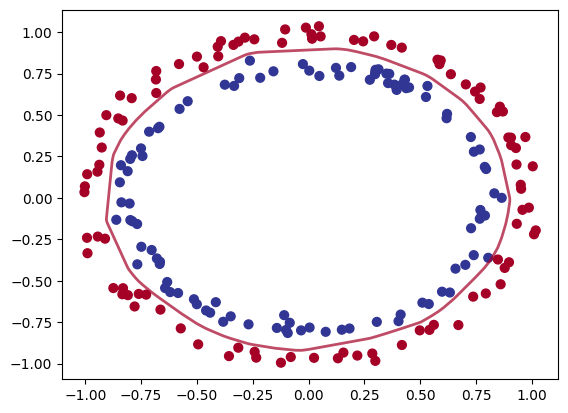

In [79]:
# decision Boundary
model_6.build(input_shape=(None, x_test.shape[-1])) # Explicitly build the model
plot_decision_boundary(model_6, x_test, y_test)